## CUTIX STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

daarcomm=pd.read_csv('../stock_data/daarcomm.csv') ## so it can be small letter. This is cool.
daarcomm=daarcomm.drop(columns=['high_price','low_price'])
daarcomm.rename(columns={'trade_date':'date'},inplace=True)
daarcomm['date']=pd.to_datetime(daarcomm['date'])
daarcomm['month']=daarcomm['date'].dt.month
daarcomm['quarter']=daarcomm['date'].dt.quarter
daarcomm['year']=daarcomm['date'].dt.year

daarcomm

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42860,DAARCOMM,2017-01-03,0.50,0.50,0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43420,DAARCOMM,2017-01-04,0.50,0.50,0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43530,DAARCOMM,2017-01-05,0.50,0.50,0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43640,DAARCOMM,2017-01-06,0.50,0.50,5000,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43730,DAARCOMM,2017-01-09,0.50,0.50,20000,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298049,DAARCOMM,2026-07-13,1.76,1.76,3004280,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298487,DAARCOMM,2026-07-14,1.76,1.76,760868,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298925,DAARCOMM,2026-07-15,1.66,1.66,839004,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299363,DAARCOMM,2026-07-16,1.70,1.70,1205491,2026-07-16T15:10:03.113936+00:00,7,3,2026


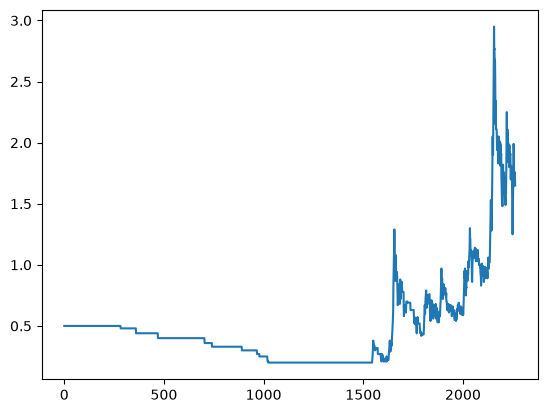

In [2]:
import matplotlib.pyplot as plt

plt.plot(daarcomm['close_price'])
plt.show()

In [3]:
daarcomm_end_month_df = (
    daarcomm
    .sort_values("date")
    .groupby(daarcomm["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

daarcomm_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45430,DAARCOMM,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47253,DAARCOMM,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49369,DAARCOMM,2017-03-31,0.50,0.50,2000,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51196,DAARCOMM,2017-04-28,0.50,0.50,22500,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53119,DAARCOMM,2017-05-31,0.50,0.50,2000,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35285,DAARCOMM,2026-03-31,1.87,1.87,2046242,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281112,DAARCOMM,2026-04-30,1.57,1.57,3107672,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284178,DAARCOMM,2026-05-29,1.84,1.84,2021037,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294107,DAARCOMM,2026-06-30,1.25,1.25,3147406,2026-06-30T15:10:03.08168+00:00,6,2,2026


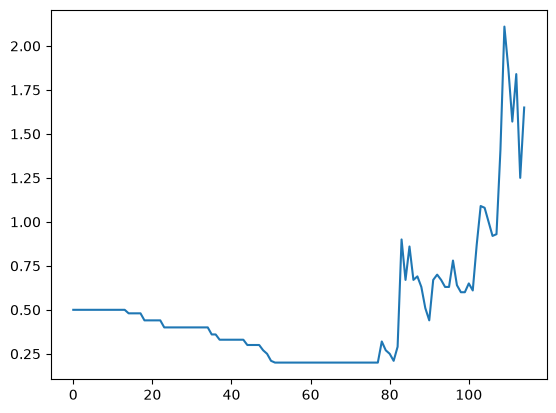

In [4]:
plt.plot(daarcomm_end_month_df['close_price'])
plt.show()

In [5]:
daarcomm_end_month_df['returns']=daarcomm_end_month_df['close_price'].pct_change()*100
daarcomm_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45430,DAARCOMM,2017-01-31,0.50,0.50,0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47253,DAARCOMM,2017-02-28,0.50,0.50,0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49369,DAARCOMM,2017-03-31,0.50,0.50,2000,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51196,DAARCOMM,2017-04-28,0.50,0.50,22500,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53119,DAARCOMM,2017-05-31,0.50,0.50,2000,2026-04-08T02:52:57.421655+00:00,5,2,2017,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
110,35285,DAARCOMM,2026-03-31,1.87,1.87,2046242,2026-03-31T15:00:02.085058+00:00,3,1,2026,-11.374408
111,281112,DAARCOMM,2026-04-30,1.57,1.57,3107672,2026-04-30T15:00:02.170664+00:00,4,2,2026,-16.042781
112,284178,DAARCOMM,2026-05-29,1.84,1.84,2021037,2026-05-29T15:00:02.455558+00:00,5,2,2026,17.197452
113,294107,DAARCOMM,2026-06-30,1.25,1.25,3147406,2026-06-30T15:10:03.08168+00:00,6,2,2026,-32.065217


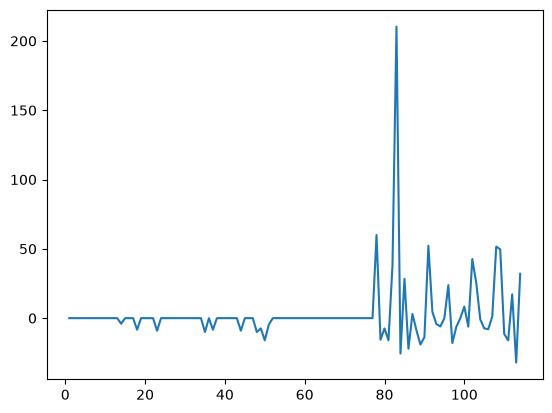

In [6]:
plt.plot(daarcomm_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(daarcomm_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-10.44106143830088), np.float64(1.5216076938080011e-18), 0, 113, {'1%': np.float64(-3.489589552580676), '5%': np.float64(-2.887477210140433), '10%': np.float64(-2.580604145195395)}, np.float64(937.8035506812176))
stationary


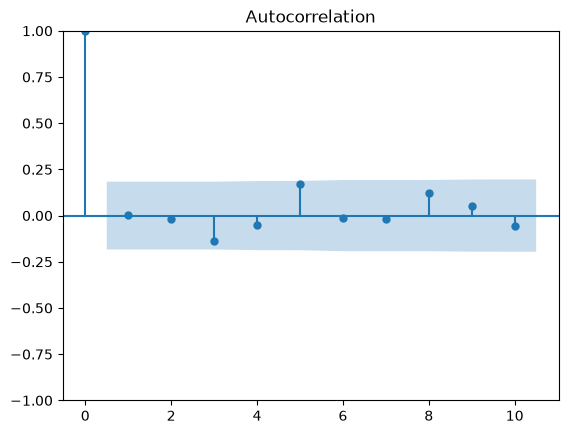

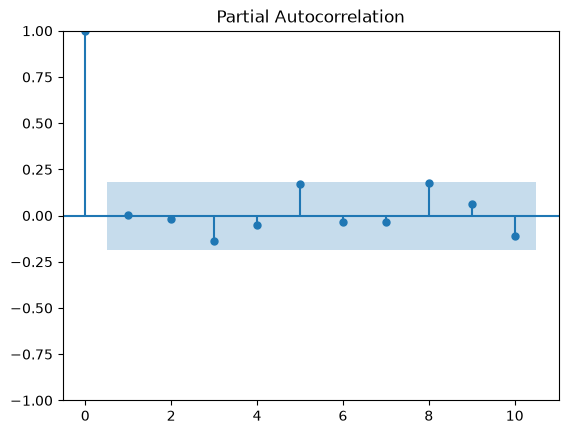

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(daarcomm_end_month_df['returns'].dropna(), lags=10)
plot_pacf(daarcomm_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=daarcomm_end_month_df['close_price'][:-10]
test=daarcomm_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -13.119480680444955]
[0, 0, 0, 0, 0, 1, -10.224279482275934]
[0, 0, 0, 0, 0, 2, -6.351366598477615]
[0, 0, 0, 0, 1, 0, -3.8515477333994363]
[0, 0, 0, 0, 1, 1, -3.8866474664391877]
[0, 0, 0, 0, 1, 2, -3.0766914847338693]
[0, 0, 0, 0, 2, 0, -4.064914923408094]
[0, 0, 0, 0, 2, 1, -2.9212026285831105]
[0, 0, 0, 0, 2, 2, -2.1540436486265886]
[0, 0, 0, 1, 0, 0, -4.2344802372141634]
[0, 0, 0, 1, 0, 1, -4.365426528348675]
[0, 0, 0, 1, 0, 2, -3.8509326218258426]
[0, 0, 0, 1, 1, 0, -3.833657552447905]
[0, 0, 0, 1, 1, 1, -4.1756735655574495]
[0, 0, 0, 1, 1, 2, -3.252122007475685]
[0, 0, 0, 1, 2, 0, -1.6253631001370183]
[0, 0, 0, 1, 2, 1, -1.6575358550344066]
[0, 0, 0, 1, 2, 2, -1.691093808672206]
[0, 0, 0, 2, 0, 0, -4.27089654077704]
[0, 0, 0, 2, 0, 1, -4.332070003707389]
[0, 0, 0, 2, 0, 2, -3.9075835325400146]
[0, 0, 0, 2, 1, 0, -3.776473261645079]
[0, 0, 0, 2, 1, 1, -5.003741280817094]
[0, 0, 0, 2, 1, 2, -3.6100245266562263]
[0, 0, 0, 2, 2, 0, -1.6560662394703352]
[0, 0, 0, 2

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
411,1,2,0,0,2,0,-23.143493
0,0,0,0,0,0,0,-13.119481
27,0,0,1,0,0,0,-12.646409
654,2,2,0,0,2,0,-12.632007
54,0,0,2,0,0,0,-12.359795
...,...,...,...,...,...,...,...
475,1,2,2,1,2,1,0.346472
448,1,2,1,1,2,1,0.347227
482,1,2,2,2,1,2,0.347454
232,0,2,2,1,2,1,0.348730


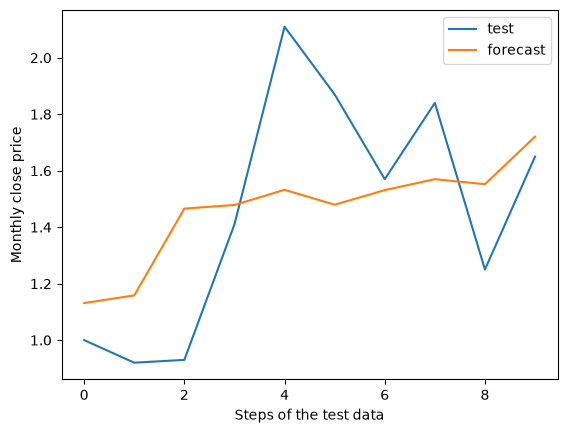

r2_score:  0.3663152035062114
rmse:  0.3197726492153764
description:  count    115.000000
mean       0.502261
std        0.370983
min        0.200000
25%        0.230000
50%        0.400000
75%        0.600000
max        2.110000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=daarcomm_end_month_df['close_price'][:-10]
y_test=daarcomm_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(1,2,0), 
seasonal_order=(0,2,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', daarcomm_end_month_df.close_price.describe())

We will work with this.